# 당뇨 예측 - CatBoost Optuna (v3 · 전체 데이터 + FE)

- 타겟: `당뇨유병` (0: 없음 / 1: 있음)
- 데이터: `hn_all_preprocessed_v2.1csv` (18~24년 통합)
- 모델: CatBoost + Optuna TPE Sampler
- Threshold: **0.50 고정**
- FE: 나이_구간 + 가족력_합계 (기본 적용)
- 목표: **Recall ≥ 0.80 유지하면서 F1 최대화**
- 검증: Stratified 5-Fold CV

In [15]:
import os
import sys
import warnings

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
from catboost import CatBoostClassifier, Pool
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold

optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings("ignore")
matplotlib.rcParams["font.family"] = "DejaVu Sans"

# ── 경로 설정 (상대 경로) ──────────────────────────────────
CURRENT_DIR = os.path.dirname(os.path.abspath(""))
BASE_DIR = os.path.join(CURRENT_DIR, "..")
DATA_PATH = os.path.join(BASE_DIR, "data", "hn_all_preprocessed_v2.1.csv")
FEATURES_DIR = os.path.join(BASE_DIR, "features")
NPY_DIR = os.path.join(BASE_DIR, "outputs", "oof")
sys.path.insert(0, FEATURES_DIR)

RANDOM_STATE = 42
THRESHOLD = 0.50
N_TRIALS = 100

## 1. 데이터 로드

In [16]:
df = pd.read_csv(DATA_PATH)
print(f"로드 완료 | shape: {df.shape}")

로드 완료 | shape: (19765, 31)


## 2. ✏️ Feature Engineering 설정
> 순서 중요: `add_age_bin` → `add_family_sum` → 나머지

In [17]:
# df = add_age_bin(df)                    # ✅ 나이_구간
# df = add_family_sum(df,                 # ✅ 가족력_합계
#                     hypertension=True,
#                     diabetes=True,
#                     dyslipidemia=True)
# df = add_bmi_bin(df)                  # ❌ BMI_구간
# df = add_alcohol_load(df)             # ❌ 음주_총부하
# df = add_exercise_total(df)           # ❌ 총운동일수
# df = add_body_features(df)            # ❌ 체형 복합
# df = add_age_family_interaction(df,   # ❌ 나이×가족력
#                                 hypertension=False, diabetes=True)

print(f"\n피처 엔지니어링 완료 | shape: {df.shape}")


피처 엔지니어링 완료 | shape: (19765, 31)


## 3. 피처 / 타겟 분리

In [18]:
TARGET = "당뇨유병"
DROP_COLS = ["고혈압유병", "당뇨유병", "이상지질혈증유병"]

data = df.dropna(subset=[TARGET]).copy()
X = data.drop(columns=DROP_COLS)
y = data[TARGET].astype(int)
neg, pos = (y == 0).sum(), (y == 1).sum()
ratio = neg / pos

print(f"샘플 수: {len(y)}  |  정상: {neg}  |  당뇨: {pos}")
print(f"불균형 비율: {ratio:.4f}:1")
print(f"사용 피처 수: {X.shape[1]}")

샘플 수: 19719  |  정상: 15062  |  당뇨: 4657
불균형 비율: 3.2343:1
사용 피처 수: 28


## 4. Optuna Objective 정의

In [19]:
def objective(trial):
    params = dict(
        iterations=trial.suggest_int("iterations", 300, 800),
        learning_rate=trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        depth=trial.suggest_int("depth", 3, 8),
        l2_leaf_reg=trial.suggest_float("l2_leaf_reg", 1.0, 10.0),
        bagging_temperature=trial.suggest_float("bagging_temperature", 0.0, 1.0),
        random_strength=trial.suggest_float("random_strength", 0.0, 1.0),
        border_count=trial.suggest_int("border_count", 32, 255),
        loss_function="Logloss",
        eval_metric="AUC",
        class_weights={0: 1.0, 1: ratio},
        early_stopping_rounds=50,
        random_seed=RANDOM_STATE,
        verbose=False,
        allow_writing_files=False,
    )
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for tr_idx, val_idx in cv.split(X, y):
        m = CatBoostClassifier(**params)
        m.fit(Pool(X.iloc[tr_idx], y.iloc[tr_idx]), eval_set=Pool(X.iloc[val_idx], y.iloc[val_idx]))
        proba = m.predict_proba(X.iloc[val_idx])[:, 1]
        pred = (proba >= THRESHOLD).astype(int)
        rec = recall_score(y.iloc[val_idx], pred)
        penalty = max(0, 0.8 - rec) * 2
        scores.append(f1_score(y.iloc[val_idx], pred) - penalty)
    return np.mean(scores)

## 5. Optuna 최적화 실행

In [20]:
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\n최적 trial: {study.best_trial.number}")
print(f"최적 score: {study.best_value:.4f}")
print("\n[최적 파라미터]")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best trial: 72. Best value: 0.55472: 100%|██████████| 100/100 [14:47<00:00,  8.88s/it]


최적 trial: 72
최적 score: 0.5547

[최적 파라미터]
  iterations: 715
  learning_rate: 0.02360560051497386
  depth: 7
  l2_leaf_reg: 6.57194590776905
  bagging_temperature: 0.012447107163414628
  random_strength: 0.3939704127052848
  border_count: 141


## 6. Optuna 최적화 과정 시각화

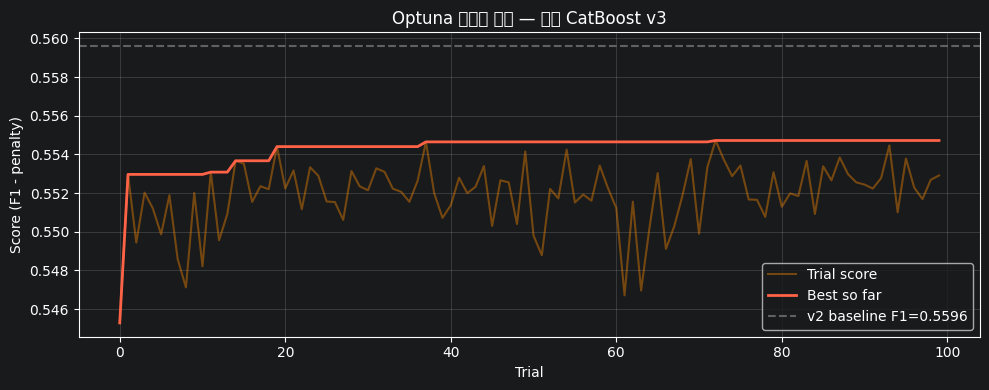

In [21]:
trial_values = [t.value for t in study.trials]
best_so_far = np.maximum.accumulate(trial_values)

plt.figure(figsize=(10, 4))
plt.plot(trial_values, alpha=0.4, color="darkorange", label="Trial score")
plt.plot(best_so_far, color="tomato", lw=2, label="Best so far")
plt.axhline(y=0.5596, color="gray", linestyle="--", alpha=0.7, label="v2 baseline F1=0.5596")
plt.xlabel("Trial")
plt.ylabel("Score (F1 - penalty)")
plt.title("Optuna 최적화 과정 — 당뇨 CatBoost v3")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. 최적 파라미터로 최종 학습 & 평가

In [22]:
best_params = dict(
    **study.best_params,
    loss_function="Logloss",
    eval_metric="AUC",
    class_weights={0: 1.0, 1: ratio},
    early_stopping_rounds=50,
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_proba = np.zeros(len(y))
fold_scores = []

print("=" * 65)
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    model = CatBoostClassifier(**best_params)
    model.fit(Pool(X_tr, y_tr), eval_set=Pool(X_val, y_val))
    proba = model.predict_proba(X_val)[:, 1]
    oof_proba[val_idx] = proba
    pred = (proba >= THRESHOLD).astype(int)
    cm_f = confusion_matrix(y_val, pred)
    fold_scores.append(
        {
            "fold": fold,
            "auc": roc_auc_score(y_val, proba),
            "f1": f1_score(y_val, pred),
            "recall": recall_score(y_val, pred),
            "precision": precision_score(y_val, pred),
            "fp": int(cm_f[0, 1]),
            "best_iter": model.best_iteration_,
        }
    )
    print(
        f"  Fold {fold} | AUC: {fold_scores[-1]['auc']:.4f} | "
        f"Recall: {fold_scores[-1]['recall']:.4f} | "
        f"F1: {fold_scores[-1]['f1']:.4f} | "
        f"best_iter: {model.best_iteration_}"
    )

scores_df = pd.DataFrame(fold_scores)
print("=" * 65)
print(
    f"  평균   | AUC: {scores_df.auc.mean():.4f}±{scores_df.auc.std():.4f} "
    f"| Recall: {scores_df.recall.mean():.4f}±{scores_df.recall.std():.4f} "
    f"| F1: {scores_df.f1.mean():.4f}±{scores_df.f1.std():.4f}"
)

  Fold 1 | AUC: 0.8251 | Recall: 0.8550 | F1: 0.5674 | best_iter: 215
  Fold 2 | AUC: 0.8080 | Recall: 0.8120 | F1: 0.5581 | best_iter: 322
  Fold 3 | AUC: 0.8050 | Recall: 0.8036 | F1: 0.5497 | best_iter: 254
  Fold 4 | AUC: 0.8094 | Recall: 0.8122 | F1: 0.5517 | best_iter: 387
  Fold 5 | AUC: 0.8001 | Recall: 0.8153 | F1: 0.5466 | best_iter: 250
  평균   | AUC: 0.8095±0.0094 | Recall: 0.8196±0.0202 | F1: 0.5547±0.0082


## 8. OOF proba 저장 (.npy)

In [23]:
os.makedirs(NPY_DIR, exist_ok=True)
npy_path = os.path.join(NPY_DIR, "oof_proba_DM_catboost_v3_optuna.npy")
oof_array = np.stack([oof_proba, y.values], axis=1)
np.save(npy_path, oof_array)
print(f"저장 완료 → {npy_path}")
loaded = np.load(npy_path)
print(f"로드 확인: shape={loaded.shape}, 일치={np.allclose(oof_array, loaded)}")

저장 완료 → /Users/Jiyeon/Desktop/final_project/ML/model/../outputs/oof/oof_proba_DM_catboost_v3_optuna.npy
로드 확인: shape=(19719, 2), 일치=True


## 9. OOF 전체 성능 & v2 baseline 비교

In [24]:
pred_oof = (oof_proba >= THRESHOLD).astype(int)
cm = confusion_matrix(y, pred_oof)
oof_auc = roc_auc_score(y, oof_proba)
oof_rec = recall_score(y, pred_oof)
oof_prec = precision_score(y, pred_oof)
oof_f1 = f1_score(y, pred_oof)
oof_acc = float((pred_oof == y).mean())

# v2 baseline (Optuna 파라미터 고정, FE 없음)
BASE = {"auc": 0.8177, "recall": 0.8074, "precision": 0.4281, "f1": 0.5596, "acc": 0.6998, "fp": 5022, "fn": 897}

print("=" * 58)
print(f"  {'지표':<12}  {'v2 baseline':>12}  {'v3 Optuna':>10}  변화")
print("=" * 58)
for label, base_v, cur_v in [
    ("AUC-ROC", BASE["auc"], oof_auc),
    ("Recall", BASE["recall"], oof_rec),
    ("Precision", BASE["precision"], oof_prec),
    ("F1-score", BASE["f1"], oof_f1),
    ("Accuracy", BASE["acc"], oof_acc),
]:
    d = cur_v - base_v
    arrow = "▲" if d > 0 else ("▼" if d < 0 else "─")
    print(f"  {label:<12}  {base_v:>12.4f}  {cur_v:>10.4f}  {arrow} {abs(d):.4f}")
print(
    f"  {'FP':<12}  {BASE['fp']:>12}  {cm[0, 1]:>10}  {'▼' if cm[0, 1] < BASE['fp'] else '▲'} {abs(cm[0, 1] - BASE['fp'])}"
)
print(
    f"  {'FN':<12}  {BASE['fn']:>12}  {cm[1, 0]:>10}  {'▼' if cm[1, 0] < BASE['fn'] else '▲'} {abs(cm[1, 0] - BASE['fn'])}"
)
print("=" * 58)
print("\n[분류 리포트]")
print(classification_report(y, pred_oof, target_names=["정상(0)", "당뇨(1)"]))

  지표             v2 baseline   v3 Optuna  변화
  AUC-ROC             0.8177      0.8091  ▼ 0.0086
  Recall              0.8074      0.8196  ▲ 0.0122
  Precision           0.4281      0.4193  ▼ 0.0088
  F1-score            0.5596      0.5548  ▼ 0.0048
  Accuracy            0.6998      0.6893  ▼ 0.0105
  FP                    5022        5287  ▲ 265
  FN                     897         840  ▼ 57

[분류 리포트]
              precision    recall  f1-score   support

       정상(0)       0.92      0.65      0.76     15062
       당뇨(1)       0.42      0.82      0.55      4657

    accuracy                           0.69     19719
   macro avg       0.67      0.73      0.66     19719
weighted avg       0.80      0.69      0.71     19719



## 10. Confusion Matrix

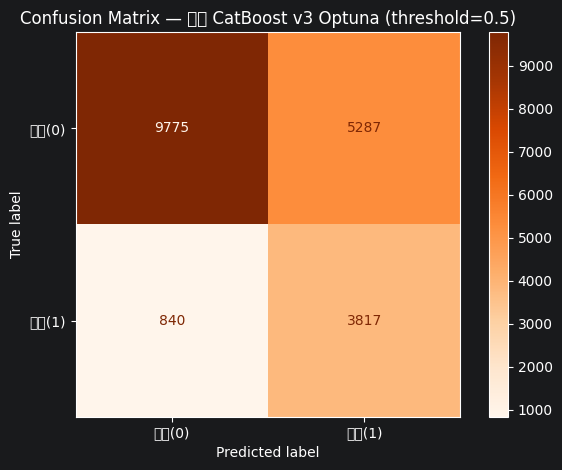

In [25]:
disp = ConfusionMatrixDisplay(cm, display_labels=["정상(0)", "당뇨(1)"])
disp.plot(cmap="Oranges")
plt.title(f"Confusion Matrix — 당뇨 CatBoost v3 Optuna (threshold={THRESHOLD})")
plt.tight_layout()
plt.show()

## 11. Feature Importance (5-Fold 평균)

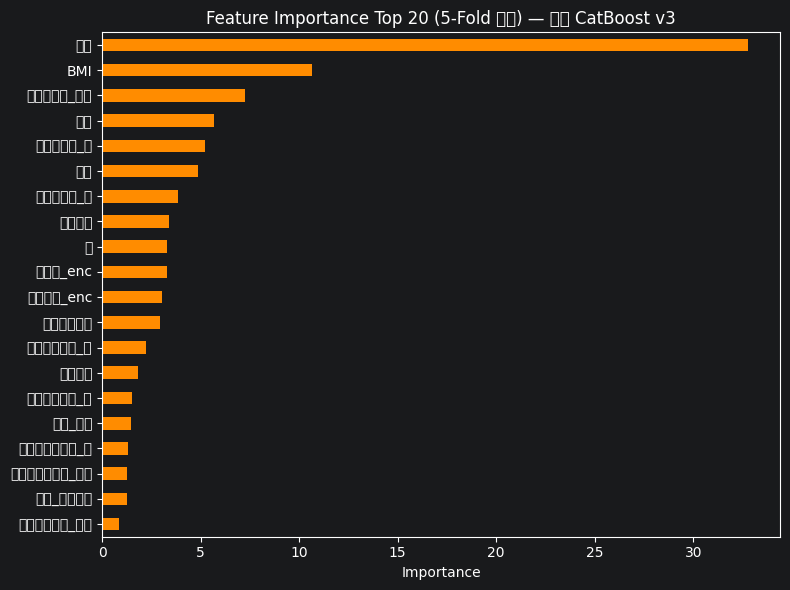

나이            32.765349
BMI           10.661634
당뇨가족력_형제       7.243040
체중             5.703869
당뇨가족력_모        5.212411
성별             4.888472
당뇨가족력_부        3.874931
걷기일수           3.394283
키              3.287896
음주량_enc        3.280289
음주빈도_enc       3.039599
근력운동일수         2.947822
고혈압가족력_모       2.226906
현재흡연           1.843780
고혈압가족력_부       1.501927
직업_무직          1.449241
고지혈증가족력_모      1.289518
고지혈증가족력_형제     1.265056
직업_관리전문        1.258714
고혈압가족력_형제      0.869079


In [26]:
fi_list = []
for fold, (tr_idx, val_idx) in enumerate(
    StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE).split(X, y), 1
):
    m = CatBoostClassifier(**best_params)
    m.fit(Pool(X.iloc[tr_idx], y.iloc[tr_idx]), eval_set=Pool(X.iloc[val_idx], y.iloc[val_idx]))
    fi_list.append(m.get_feature_importance())

fi = pd.DataFrame(fi_list, columns=X.columns).mean(axis=0).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
fi.head(20)[::-1].plot(kind="barh", color="darkorange")
plt.title("Feature Importance Top 20 (5-Fold 평균) — 당뇨 CatBoost v3")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
print(fi.head(20).to_string())

## 12. SHAP 분석 (OOF 전체 기준)

SHAP Fold 1 완료
SHAP Fold 2 완료
SHAP Fold 3 완료
SHAP Fold 4 완료
SHAP Fold 5 완료


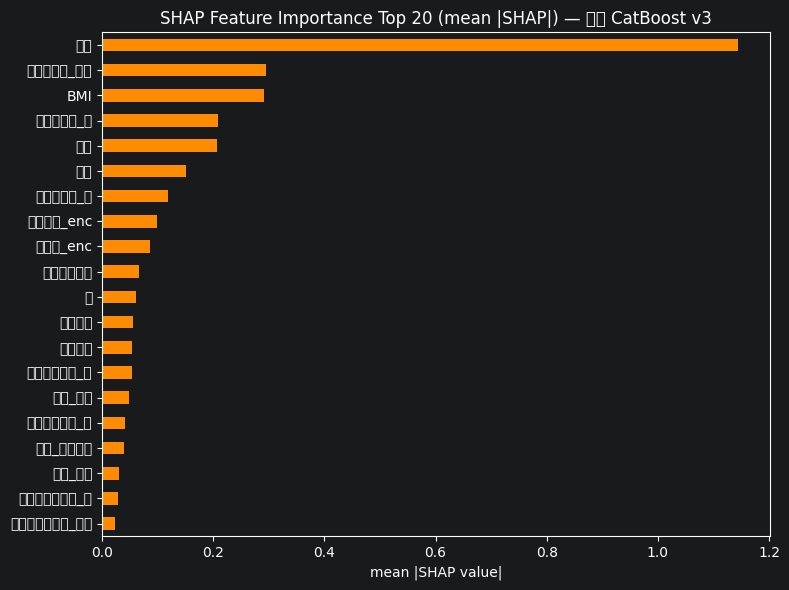

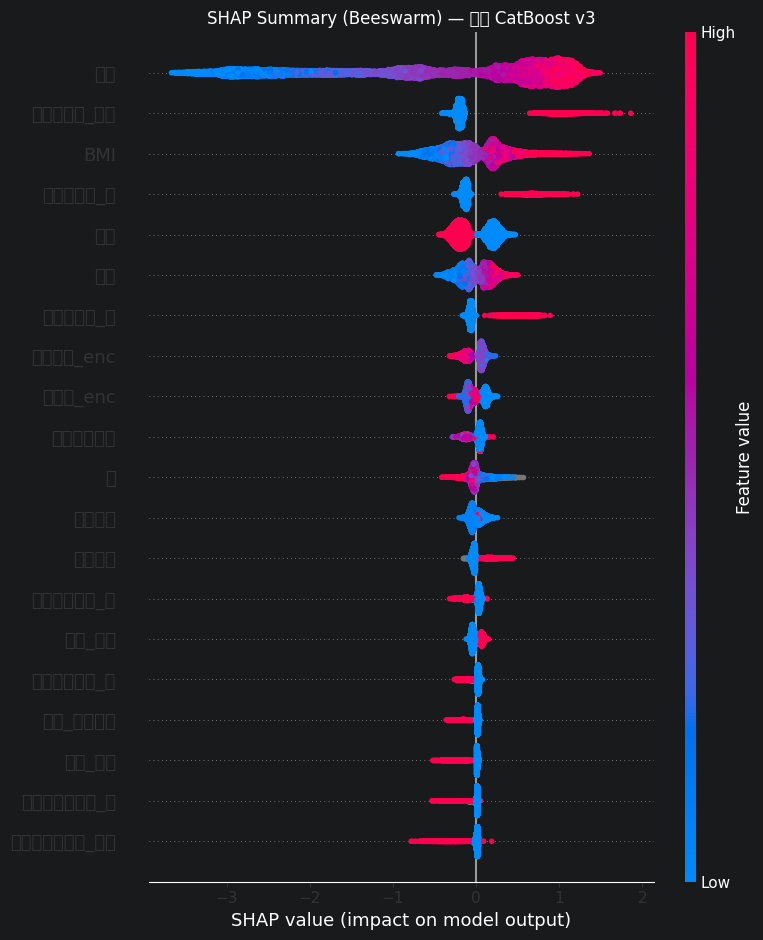

[SHAP Top 15]
   1. 나이: 1.1441
   2. 당뇨가족력_형제: 0.2954
   3. BMI: 0.2912
   4. 당뇨가족력_모: 0.2080
   5. 성별: 0.2060
   6. 체중: 0.1505
   7. 당뇨가족력_부: 0.1180
   8. 음주빈도_enc: 0.0984
   9. 음주량_enc: 0.0859
  10. 근력운동일수: 0.0657
  11. 키: 0.0607
  12. 걷기일수: 0.0556
  13. 현재흡연: 0.0539
  14. 고혈압가족력_모: 0.0530
  15. 직업_무직: 0.0486


In [27]:
import shap

skf2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
shap_values = np.zeros(X.shape)

for fold, (tr_idx, val_idx) in enumerate(skf2.split(X, y), 1):
    m = CatBoostClassifier(**best_params)
    m.fit(Pool(X.iloc[tr_idx], y.iloc[tr_idx]), eval_set=Pool(X.iloc[val_idx], y.iloc[val_idx]))
    explainer = shap.TreeExplainer(m)
    shap_values[val_idx] = explainer.shap_values(X.iloc[val_idx])
    print(f"SHAP Fold {fold} 완료")

mean_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
mean_shap.head(20)[::-1].plot(kind="barh", color="darkorange")
plt.title("SHAP Feature Importance Top 20 (mean |SHAP|) — 당뇨 CatBoost v3")
plt.xlabel("mean |SHAP value|")
plt.tight_layout()
plt.show()

shap.summary_plot(shap_values, X, plot_type="dot", max_display=20, show=False)
plt.title("SHAP Summary (Beeswarm) — 당뇨 CatBoost v3", fontsize=12)
plt.tight_layout()
plt.show()

print("[SHAP Top 15]")
for i, (feat, val) in enumerate(mean_shap.head(15).items(), 1):
    print(f"  {i:2d}. {feat}: {val:.4f}")

## 13. DB 로그 저장

In [28]:
sys.path.insert(0, BASE_DIR)
from model_logger import ModelLogger

logger = ModelLogger(os.path.join(BASE_DIR, "model_result.db"))

base_cols = pd.read_csv(DATA_PATH).columns.tolist()
fe_cols = [c for c in X.columns if c not in base_cols]
fe_note = f"FE 적용: {fe_cols}" if fe_cols else "FE 없음"

run_id = logger.log_run(
    target_var="당뇨",
    model_name="CatBoost",
    stage="v3_optuna",
    hyperparams={
        "learning_rate": best_params["learning_rate"],
        "depth": best_params["depth"],
        "n_estimators": best_params["iterations"],
        "class_weight": {0: 1.0, 1: round(ratio, 4)},
        "l2_leaf_reg": best_params["l2_leaf_reg"],
        "bagging_temperature": best_params["bagging_temperature"],
        "random_strength": best_params["random_strength"],
        "border_count": best_params["border_count"],
    },
    data_info={
        "feature_count": X.shape[1],
        "train_test_split": "5-Fold CV",
        "scaling_method": "None",
    },
    oof_metrics={
        "accuracy": oof_acc,
        "recall": oof_rec,
        "precision": oof_prec,
        "f1_score": oof_f1,
        "auc_roc": oof_auc,
        "cm": cm.tolist(),
    },
    fold_scores=scores_df.to_dict("records"),
    top_features=mean_shap.head(15).to_dict(),
    note=f"v3 Optuna {N_TRIALS} trials. 데이터: hn_all_v2. {fe_note}",
)
print(f"저장 완료 → run_id: {run_id}  |  {fe_note}")
print(logger.compare_runs().to_string(index=False))

[ModelLogger] 저장 완료 | run_id=41 | 당뇨 CatBoost (v3_optuna)
저장 완료 → run_id: 41  |  FE 없음
 run_id          created_at target_var model_name          stage  auc_roc   recall  precision  f1_score  accuracy
     41 2026-05-19 11:40:29         당뇨   CatBoost      v3_optuna 0.809118 0.819626   0.419266  0.554756  0.689284
     40 2026-05-19 11:37:01        고혈압   CatBoost      v3_optuna 0.868414 0.838299   0.603994  0.702115  0.770908
     39 2026-05-19 11:32:44     이상지질혈증    XGBoost      v3_optuna 0.788788 0.850818   0.447786  0.586760  0.659817
     38 2026-05-19 11:22:21        고혈압   CatBoost      v3_optuna 0.871250 0.839095   0.606238  0.703909  0.772653
     37 2026-05-19 11:20:39     이상지질혈증    XGBoost      v3_optuna 0.790924 0.884071   0.439251  0.586901  0.646728
     36 2026-05-19 11:16:22         당뇨   CatBoost      v3_optuna 0.817880 0.815546   0.427992  0.561378  0.699021
     35 2026-05-18 21:03:29     이상지질혈증    XGBoost         fe_exp 0.786431 0.841631   0.447801  0.584572  0.660443
 